# GPAT

Gridded Plume Analysis Tool (GPAT) modelling framework. This simulates flight trajectories, estimates fuel burn and emissions, models dispersion effects, and aggregates plume data to a common Eulerian grid for further photochemical and microphysical processing.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from dataclasses import asdict
from pycontrails.models.gpat.gpat import GPAT, SimParams, FlParams, PlParams, MetParams, ChemParams, dict_to_dataclass
import os
import holoviews as hv
import hvplot.pandas
import hvplot.xarray

In [2]:
# global simulation parameters
sim_params = {
    "t_fl": (pd.to_datetime("2022-01-20 13:00:00"), pd.Timedelta(minutes=1), pd.Timedelta(hours=1)),# (start time, time step, run time)
    "t_pl": (pd.to_datetime("2022-01-20 13:00:00"), pd.Timedelta(minutes=1), pd.Timedelta(hours=2)),# (start time, time step, max age)
    "t_sim": (pd.to_datetime("2022-01-20 12:00:00"), pd.Timedelta(seconds=20), pd.Timedelta(hours=4)),# (start time, time step, run time)
    "t_out": (pd.to_datetime("2022-01-20 12:00:00"), pd.Timedelta(minutes=1), pd.Timedelta(hours=4)),# (start time, time step, run time)
    "lat_bounds": (0.0, 1.0),  # lat bounds [deg]
    "lon_bounds": (0.0, 1.0),  # lon bounds [deg]
    "alt_bounds": (10000, 11000),  # alt bounds [m]
    "hres_sim_c": 0.05,  # coarse horizontal resolution [deg]
    "vres_sim_c": 500,  # coarse vertical resolution [m]
    "hres_sim_f": 0.001,  # fine horizontal resolution [deg]
    "vres_sim_f": 100,  # fine vertical resolution [m]

    "run_path": "/home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/",
    "data_path": "/home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/data/", # "/projects/Impact_of_aviation_on_climate
    "job_id": "GPAT_Feb_2026_test_2_ac",
}

In [3]:
#flight trajectory parameters
fl_params = {
    "mode": "synthetic",
    "file": None,  # flight trajectory file

    "ac_type": "A320",  # aircraft type
    "fl0_speed": 150.0,  # m/s
    "fl0_heading": 45.0,  # deg
    "fl0_coords0": (0.1, 0.1, 10500),  # lat, lon, alt [deg, deg, m]
    "sep_dist": (10000, 5000, 0),  # dx, dy, dz [m]
    "n_ac": 2,  # number of aircraft
}

In [4]:
# plume dispersion parameters
pl_params = {
    "depth": 50.0,  # initial plume depth, [m]
    "width": 50.0,  # initial plume width, [m]
    "verbose_outputs": False,  # print verbose outputs
    "n_slices": 3,  # number of slices in the plume
    "f_max": 0.99,  # maximum fraction of total emissions in any slice
    "shear": 0.01,  # shear [m/s]
    }

In [5]:
# meteorology parameters
met_params = {
    "eastward_wind": 5.0,  # m/s
    "northward_wind": 3.0,  # m/s
    "lagrangian_tendency_of_air_pressure": 0.0,  # m/s
}

In [6]:
# chemistry parameters
chem_params = {
    "run_chem": True,
    "species_emi": ("NO", "CO", "SO2"),
    # "species_pl": ("NO", "CO", "SO2"),
    "species_pl": ("NO", "NO2", "O3", "NO3", "N2O5",
                      "HNO3", "HONO", "HO2NO2","PAN", 
                      "CH3O2NO2","H2O2", "CH3OOH",
                      "CO", "CH4", "HCHO", "SO2", "SA"),
    "species_out": ("O3", "NO2", "NO", "NO3", "N2O5", 
                    "HNO3", "HONO", "HO2", "OH", "H2O2",
                    "CO", "CH4", "CH3O2","HO2NO2", "PAN", "SO2" )
}

In [7]:
sim_params = SimParams(**sim_params)
fl_params = FlParams(**fl_params)
pl_params = PlParams(**pl_params)
met_params = MetParams(**met_params)
chem_params = ChemParams(**chem_params)

gpat = GPAT(sim_params, fl_params, pl_params, met_params, chem_params)

In [8]:
gpat.preprocess_gpat()

/home/ktait98/miniconda3/envs/contrails/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:234: UserWarning: no explicit representation of timezones available for np.datetime64
  return data.astype(dtype, **kwargs)


flight 0 done
flight 1 done


/home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/gpat.py:622: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fl[i].dataframe[column] = fl[i].dataframe[column].fillna(method="ffill")
/home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/gpat.py:685: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fl[i][column] = fl[i][column].fillna(method="ffill")
/home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/gpat.py:685: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fl[i][column] = fl[i][column].fillna(method="ffill")
/home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/gpat.py:898: RuntimeWarning: invalid value encountered in cast
  age_seconds = np.where(np.isnat(age_values), 0, (age_values / np

Saved /home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/data/inputs/GPAT_Feb_2026_test_2_ac/boxm_ds.nc
Saved /home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/data/inputs/GPAT_Feb_2026_test_2_ac/fl_ds.nc
Saved /home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/data/inputs/GPAT_Feb_2026_test_2_ac/pl_ds.nc
Saved /home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/data/outputs/GPAT_Feb_2026_test_2_ac/boxm_out.nc
Saved /home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/data/outputs/GPAT_Feb_2026_test_2_ac/patch_table.nc
Saved /home/ktait98/GPAT2026/pycontrails_kt/pycontrails/models/gpat/data/outputs/GPAT_Feb_2026_test_2_ac/pl_out.nc


In [9]:
gpat.eval()

 FL_DS SUMMARY:
   NSEG =           30
   IS_OPEN =  T
   NCID =        65536
 PL_DS SUMMARY:
   NSEG =           30
   NSEMI =            3
   NTPL =          129
   IS_OPEN =  T
   NCID =       131072
 BOXM_DS SUMMARY:
   NCELL =          800
   NSBOXM =          219
   NTBOXM =          721
   IS_OPEN =  T
   NCID =       196608


In [10]:
fl_ds = xr.open_dataset(f"{gpat.inputs_job}/fl_ds.nc")
fl_ds

<xarray.Dataset> Size: 7kB
Dimensions:               (seg_id: 30)
Coordinates:
    flight_id             (seg_id) int64 240B ...
    waypoint              (seg_id) int64 240B ...
  * seg_id                (seg_id) int64 240B 1 2 3 4 5 6 ... 25 26 27 28 29 30
Data variables: (12/16)
    longitude             (seg_id) float64 240B ...
    latitude              (seg_id) float64 240B ...
    level                 (seg_id) float64 240B ...
    altitude              (seg_id) float64 240B ...
    time                  (seg_id) <U20 2kB ...
    true_airspeed         (seg_id) float64 240B ...
    ...                    ...
    thrust                (seg_id) float64 240B ...
    rocd                  (seg_id) float64 240B ...
    fuel_flow_per_engine  (seg_id) float64 240B ...
    thrust_setting        (seg_id) float64 240B ...
    time_rel_s            (seg_id) int64 240B ...
    time_idx              (seg_id) int64 240B ...
Attributes:
    description:  Flight trajectory and emissions data for BOXM

In [23]:
from IPython.display import clear_output
clear_output(wait=True)

pl_ds = xr.open_dataset(f"{gpat.inputs_job}/pl_ds.nc")
pl_ds.to_dataframe().reset_index()[["time", "longitude", "latitude", "altitude", "width", "depth", "heading", "flight_id", "seg_id"]].dropna()

,time,longitude,latitude,altitude,width,depth,heading,flight_id,seg_id
6,2022-01-20T13:01:00Z,0.105396,0.103237,10500.0,162.239393,118.335541,45.565357,1,1
7,2022-01-20T13:01:00Z,0.105396,0.103237,10500.0,162.239393,118.335541,45.565357,1,1
8,2022-01-20T13:01:00Z,0.105396,0.103237,10500.0,162.239393,118.335541,45.565357,1,1
9,2022-01-20T13:01:00Z,0.159869,0.159171,10500.0,117.642577,109.535992,45.565357,1,1
10,2022-01-20T13:01:00Z,0.159869,0.159171,10500.0,117.642577,109.535992,45.565357,1,1
...,...,...,...,...,...,...,...,...,...
22597,2022-01-20T13:25:00Z,0.973626,0.901176,10500.0,1064.347975,188.047801,45.558271,2,30
22598,2022-01-20T13:25:00Z,0.973626,0.901176,10500.0,1064.347975,188.047801,45.558271,2,30
22599,2022-01-20T13:25:00Z,0.973626,0.901176,10500.0,1064.347975,188.047801,45.558271,2,30
22600,2022-01-20T13:25:00Z,0.973626,0.901176,10500.0,1064.347975,188.047801,45.558271,2,30


In [12]:
pl_ds["width"].sel(seg_id=1, ht='tail').values

array([  117.64439677,   162.23939279,   221.10043202,   288.04969035,
         360.58881764,   437.58581733,   518.44444256,   602.80590521,
         690.42959012,   781.13984596,   874.79988943,   971.29793352,
        1070.53928793,  1172.44158409,  1276.93173396,  1383.94390179,
        1493.41809488,  1605.29914845,  1719.53597054,  1836.08096437,
        1954.88957526,  2075.91992767,  2199.13252874,  2324.49002235,
        2451.95698202,  2581.49973444,  2713.08620745,  2846.68579789,
        2982.26925573,  3119.80858179,  3259.2769368 ,  3400.64856025,
        3543.89869738,  3689.00353342,  3835.94013394,  3984.68639075,
        4135.22097239,  4287.52327895,  4441.57340058,  4597.35207932,
        4754.84067389,  4914.02112721,  5074.87593625,  5237.3881241 ,
        5401.541214  ,  5567.31920514,  5734.70655012,  5903.68813389,
        6074.24925399,  6246.37560217,  6420.05324703,  6595.26861775,
        6772.00848883,  6950.2599657 ,  7130.01047114,  7311.2477325 ,
      

In [13]:
# Matplotlib time slider (ipympl): trajectories + plume width (tail only)
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import ipywidgets as widgets
from IPython.display import display


# gpat.analysis.plot_plumes()

sections: 4 vertices: 128 triangles: 256
estimated volume (m^3): 273373569.5804222


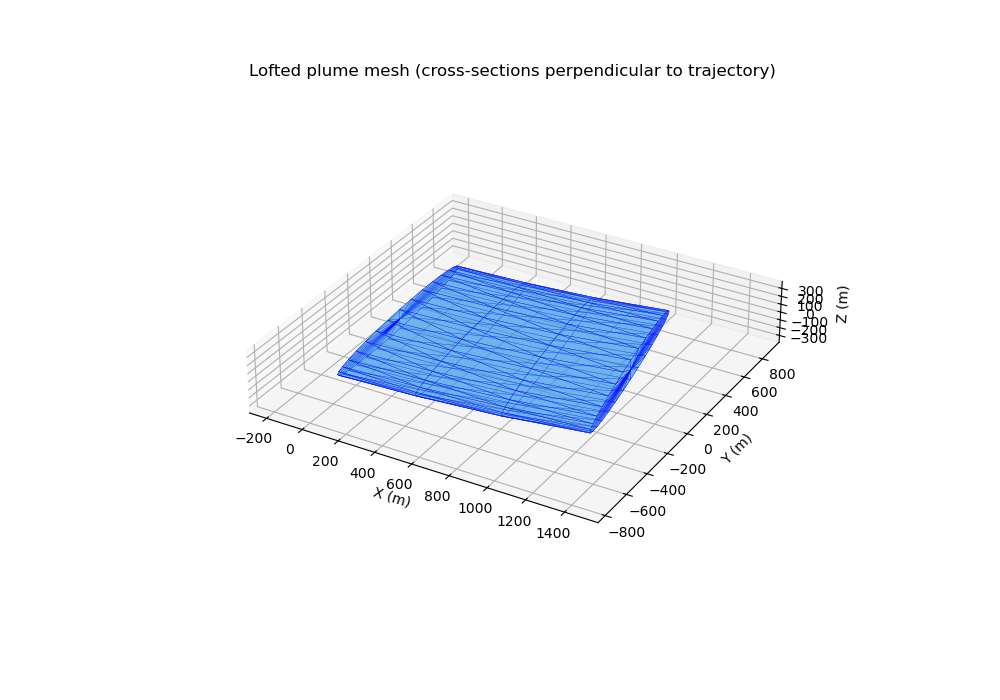

In [14]:
gpat.analysis.plot_plumes_3d_ani()

In [15]:
from IPython.display import clear_output
clear_output(wait=True)

boxm_out = xr.open_dataset(f"{gpat.outputs_job}/boxm_out.nc")

boxm_out["time_idx"].values

array([  1,   4,   7,  10,  13,  16,  19,  22,  25,  28,  31,  34,  37,
        40,  43,  46,  49,  52,  55,  58,  61,  64,  67,  70,  73,  76,
        79,  82,  85,  88,  91,  94,  97, 100, 103, 106, 109, 112, 115,
       118, 121, 124, 127, 130, 133, 136, 139, 142, 145, 148, 151, 154,
       157, 160, 163, 166, 169, 172, 175, 178, 181, 184, 187, 190, 193,
       196, 199, 202, 205, 208, 211, 214, 217, 220, 223, 226, 229, 232,
       235, 238, 241, 244, 247, 250, 253, 256, 259, 262, 265, 268, 271,
       274, 277, 280, 283, 286, 289, 292, 295, 298, 301, 304, 307, 310,
       313, 316, 319, 322, 325, 328, 331, 334, 337, 340, 343, 346, 349,
       352, 355, 358, 361, 364, 367, 370, 373, 376, 379, 382, 385, 388,
       391, 394, 397, 400, 403, 406, 409, 412, 415, 418, 421, 424, 427,
       430, 433, 436, 439, 442, 445, 448, 451, 454, 457, 460, 463, 466,
       469, 472, 475, 478, 481, 484, 487, 490, 493, 496, 499, 502, 505,
       508, 511, 514, 517, 520, 523, 526, 529, 532, 535, 538, 54

In [16]:
gpat.patch_table

<xarray.Dataset> Size: 512B
Dimensions:          (row: 0, species_out: 16)
Coordinates:
  * row              (row) int64 0B 
    patch_id         (row) int64 0B 
  * species_out      (species_out) <U6 384B 'O3' 'NO2' 'NO' ... 'PAN' 'SO2'
    species_out_num  (species_out) int64 128B 6 4 8 5 7 14 ... 21 22 15 198 16
    time             (row) object 0B 
    time_rel_s       (row) int64 0B 
    time_idx         (row) int64 0B 
    latitude_f       (row) float64 0B 
    longitude_f      (row) float64 0B 
    altitude_f       (row) float64 0B 
    level_f          (row) float64 0B 
Data variables:
    Y_del_f          (row, species_out) float64 0B dask.array<chunksize=(0, 16), meta=np.ndarray>
Attributes:
    description:  Fine grid plume patch output for BOXM

In [17]:
from IPython.display import clear_output
clear_output(wait=True)

pl_out = xr.open_dataset(f"{gpat.outputs_job}/pl_out.nc")
pl_out


<xarray.Dataset> Size: 1MB
Dimensions:         (seg_id: 30, time: 241, species_pl: 17)
Coordinates:
    flight_id       (seg_id) int64 240B ...
    waypoint        (seg_id) int64 240B ...
  * seg_id          (seg_id) int64 240B 1 2 3 4 5 6 7 8 ... 24 25 26 27 28 29 30
  * time            (time) <U20 19kB '2022-01-20T12:00:00Z' ... '2022-01-20T1...
  * species_pl      (species_pl) <U8 544B 'NO' 'NO2' 'O3' ... 'HCHO' 'SO2' 'SA'
    species_pl_num  (species_pl) int64 136B ...
    time_rel_s      (time) int64 2kB ...
    time_idx        (time) int64 2kB ...
Data variables:
    pl_mass         (seg_id, species_pl, time) float64 983kB ...
Attributes:
    description:  Plume segment output for BOXM

In [18]:
from IPython.display import clear_output
clear_output(wait=True)

np.set_printoptions(threshold=np.inf, linewidth=2000)
print(pl_out["pl_mass"].isel(species_pl=15, time=slice(60, 80)).values)

[[0.02920443 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.02920443 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.02920443 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.02920443 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.02920443 0.         0.         0.         0.         0.     

In [19]:
pl_ds["species_emi_num"].values
pl_ds["emi_pl_mass"].isel(seg_id=0).to_pandas()
pl_ds["emi_pl_mass"].max("seg_id").to_pandas()

print(pl_ds["emi_pl_mass"].max("seg_id").to_pandas().to_string())

species_emi
NO     0.313127
CO     0.014248
SO2    0.029204


In [20]:
pl_out["pl_mass"].max(("seg_id","time")).to_pandas()

species_pl
NO          0.313127
NO2         0.000000
O3          0.000000
NO3         0.000000
N2O5        0.000000
HNO3        0.000000
HONO        0.000000
HO2NO2      0.000000
PAN         0.000000
CH3O2NO2    0.000000
H2O2        0.000000
CH3OOH      0.000000
CO          0.014248
CH4         0.000000
HCHO        0.000000
SO2         0.029204
SA          0.000000
Name: pl_mass, dtype: float64

In [21]:
pd.DataFrame({
    "species_emi": pl_ds["species_emi"].values,
    "species_emi_num": pl_ds["species_emi_num"].values,
})

pd.DataFrame({
    "species_pl": pl_out["species_pl"].values,
    "species_pl_num": pl_out["species_pl_num"].values,
})

print(pd.DataFrame({
    "species_emi": pl_ds["species_emi"].values,
    "species_emi_num": pl_ds["species_emi_num"].values,
}).to_string(index=False))

print(pd.DataFrame({
    "species_pl": pl_out["species_pl"].values,
    "species_pl_num": pl_out["species_pl_num"].values,
}).to_string(index=False))

species_emi  species_emi_num
         NO                8
         CO               11
        SO2               16
species_pl  species_pl_num
        NO               8
       NO2               4
        O3               6
       NO3               5
      N2O5               7
      HNO3              14
      HONO              13
    HO2NO2              15
       PAN             198
  CH3O2NO2             217
      H2O2              12
    CH3OOH             144
        CO              11
       CH4              21
      HCHO              39
       SO2              16
        SA              20
